# Post-process charge data

## Install and import packages

In [ ]:
!pip install --upgrade seaborn
!pip install plotly

In [1]:
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
import numpy as np
import pandas as pd
import seaborn as sns

## Data Inspection and Cleaning

### Load Synthetic Data

In [2]:
# Load charge data
charge_data = pd.read_csv('./Data_saved/Global/Generated_data_vin2_kl0_3_400epochs/kaggle/working/KoVAE/Generated_data/EV_generated_data.csv')
# Add a column id to keep the number of the row
charge_data['id'] = charge_data.index
charge_data = charge_data[charge_data['event'] == 1].reset_index(drop=True)
charge_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6312 entries, 0 to 6311
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   odo               6312 non-null   float64
 1   end_odo           6312 non-null   float64
 2   soc               6312 non-null   float64
 3   end_soc           6312 non-null   float64
 4   event             6312 non-null   int64  
 5   charge_mode       6312 non-null   int64  
 6   duration_minutes  6312 non-null   float64
 7   id                6312 non-null   int64  
dtypes: float64(5), int64(3)
memory usage: 394.6 KB


### Data description

In [3]:
# Remove duplicates
charge_data = charge_data.drop_duplicates()

# Print how many records remain
print(f"Number of records after removing duplicates: {len(charge_data)}")

Number of records after removing duplicates: 6312


In [4]:
# Check for missing values and print records with them
nan_count = charge_data.isna().sum()
print("| Features | NaN-counter |")
print(nan_count)
print("|----------|-------------|")

print("\n🔍 Records with missing values:\n")

records_with_nan = charge_data[charge_data.isna().any(axis=1)]

length = len(records_with_nan)
if length > 0:
    records_with_nan.head(length)

| Features | NaN-counter |
odo                 0
end_odo             0
soc                 0
end_soc             0
event               0
charge_mode         0
duration_minutes    0
id                  0
dtype: int64
|----------|-------------|

🔍 Records with missing values:



In [5]:
# statistics of the dataset for odo, end_odo, soc, end_soc
print("Statistics of the dataset:")
charge_data[['odo', 'end_odo', 'soc', 'end_soc']].describe().T

Statistics of the dataset:


,count,mean,std,min,25%,50%,75%,max
odo,6312.0,12507.234096,4916.470369,2858.585851,8684.521311,12161.471544,15734.236680,23073.617294
end_odo,6312.0,12520.426940,4872.230587,3098.133384,8727.322429,12201.502663,15765.025752,23177.030140
soc,6312.0,47.162034,9.596738,16.590575,40.413425,47.010366,53.906880,74.964879
end_soc,6312.0,59.654556,9.814611,26.169560,52.678645,59.815924,66.823873,87.304615


In [6]:
# Add charge 
charge_data['charge'] =  charge_data['end_soc'] - charge_data['soc']

# Add min_per_perc_of_battery and charge_per_min
charge_data['min_per_perc_of_battery'] = charge_data.apply(
    lambda row: row['duration_minutes'] / row['charge'] if row['charge'] != 0 else 0,
    axis=1
)

charge_data['charge_per_min'] = charge_data.apply(
    lambda row: row['charge'] / row['duration_minutes'] if row['duration_minutes'] != 0 else 0,
    axis=1
)

#Print statistics
print("\n🔋 Statistics on charge:\n", charge_data['charge'].describe())
print("\n🔋 Statistics on min_per_perc_of_battery:\n", charge_data['min_per_perc_of_battery'].describe())
print("\n🔋 Statistics on charge_per_min:\n", charge_data['charge_per_min'].describe())


🔋 Statistics on charge:
 count    6312.000000
mean       12.492522
std         9.513219
min        -6.587512
25%         6.685707
50%        10.442901
75%        14.445077
max        50.781258
Name: charge, dtype: float64

🔋 Statistics on min_per_perc_of_battery:
 count      6312.000000
mean         46.435949
std        1453.409712
min       -4040.520481
25%           7.980443
50%          16.815162
75%          28.384861
max      111541.620152
Name: min_per_perc_of_battery, dtype: float64

🔋 Statistics on charge_per_min:
 count    6312.000000
mean        0.176502
std         0.382257
min        -0.104639
25%         0.034024
50%         0.057074
75%         0.118207
max         5.079144
Name: charge_per_min, dtype: float64


In [7]:
# Identify records with negative duration
negative_duration_records = charge_data[(charge_data['duration_minutes'] <= 0)]

length = negative_duration_records.shape[0]
print(f"Number of records with negative duration: {length}")
if length > 0:  
    negative_duration_records.head(length)

Number of records with negative duration: 0


In [8]:
# Remove records with negative duration
charge_data = charge_data.drop(negative_duration_records.index).reset_index(drop=True)

In [9]:
# Identify snapshot records (data with no changes in soc, odo, and duration)
snapshot_records = charge_data[(charge_data['soc'] == charge_data['end_soc']) & (charge_data['end_odo'] == charge_data['odo']) & (charge_data['duration_minutes'] == 0)]

length = snapshot_records.shape[0]
print(f"Number of snapshot records: {length}")
if length > 0:
    snapshot_records.head(length)

Number of snapshot records: 0


In [10]:
# Remove snapshot records
charge_data = charge_data.drop(snapshot_records.index).reset_index(drop=True)

In [11]:
# Identify stationary records (data with no changes in soc, but positive duration)
stationary_records = charge_data[(charge_data['soc'] == charge_data['end_soc']) & (charge_data['duration_minutes'] > 0)]

length = stationary_records.shape[0]
print(f"Number of stationary rows: {length}")
if length > 0:
    stationary_records.head(length)

Number of stationary rows: 0


In [12]:
# Remove stationary records
charge_data = charge_data.drop(stationary_records.index).reset_index(drop=True)

In [13]:
# Identify records with end_soc [%] < soc [%]   
anomalous_soc_records = charge_data[(charge_data['end_soc'] < charge_data['soc'])]

length = anomalous_soc_records.shape[0]
print(f"Number of anomalous soc records: {length}")
if length > 0:
    anomalous_soc_records.head(length)

Number of anomalous soc records: 103


In [14]:
# Remove anomalous soc records
charge_data = charge_data.drop(anomalous_soc_records.index).reset_index(drop=True)

In [ ]:
'''
NOT TO RUN FOR THE MOMENT



# Identify anomalous movement records 
anomalous_movement_records = charge_data[(charge_data['end_odo'] != charge_data['odo'])]
print(f"Number of anamalous rows: {anomalous_movement_records.shape[0]}")

charge_data = charge_data[~(charge_data['end_odo'] < charge_data['odo'])].reset_index(drop=True)
anomalous_movement_records.head(len(anomalous_movement_records))'''

In [15]:
# Identify records with high charge per minute
###########################
MAX_CHARGE_PER_MIN = 1.10 #
###########################


anomalous_charge_records = charge_data[(charge_data['charge_per_min'] > MAX_CHARGE_PER_MIN)]

length = anomalous_charge_records.shape[0]
print(f"Number of records with charge per minute > {MAX_CHARGE_PER_MIN}: {length}")
if length > 0:
    anomalous_charge_records.head(length)

Number of records with charge per minute > 1.1: 246


In [16]:
# Remove anomalous charge records
charge_data = charge_data.drop(anomalous_charge_records.index).reset_index(drop=True)

In [17]:
charge_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5963 entries, 0 to 5962
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   odo                      5963 non-null   float64
 1   end_odo                  5963 non-null   float64
 2   soc                      5963 non-null   float64
 3   end_soc                  5963 non-null   float64
 4   event                    5963 non-null   int64  
 5   charge_mode              5963 non-null   int64  
 6   duration_minutes         5963 non-null   float64
 7   id                       5963 non-null   int64  
 8   charge                   5963 non-null   float64
 9   min_per_perc_of_battery  5963 non-null   float64
 10  charge_per_min           5963 non-null   float64
dtypes: float64(8), int64(3)
memory usage: 512.6 KB


## Data Visualization and Comparative Analysis

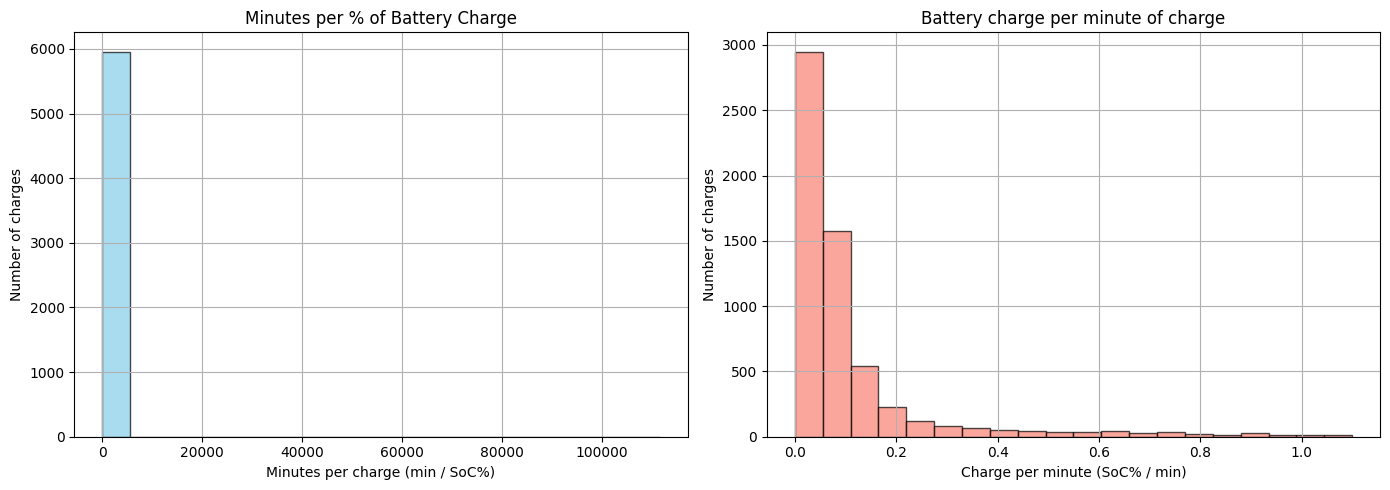

In [18]:
# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Minutes per % battery
axes[0].hist(
    charge_data['min_per_perc_of_battery'],
    bins=20,
    alpha=0.7,
    color='skyblue',
    edgecolor='black'
)
axes[0].set_title('Minutes per % of Battery Charge')
axes[0].set_xlabel('Minutes per charge (min / SoC%)')
axes[0].set_ylabel('Number of charges')
axes[0].grid(True)

# Discharge per km
axes[1].hist(
    charge_data['charge_per_min'],
    bins=20,
    alpha=0.7,
    color='salmon',
    edgecolor='black'
)
axes[1].set_title('Battery charge per minute of charge')
axes[1].set_xlabel('Charge per minute (SoC% / min)')
axes[1].set_ylabel('Number of charges')
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [19]:
charge_data.head()

,odo,end_odo,soc,end_soc,event,charge_mode,duration_minutes,id,charge,min_per_perc_of_battery,charge_per_min
0,14045.522735,14868.926146,38.642248,51.157303,1,1,206.314430,7,12.515055,16.485299,0.060660
1,14287.449622,14562.316705,43.023250,57.581932,1,1,517.307471,8,14.558682,35.532576,0.028143
2,14453.140002,13854.796484,45.336082,48.164892,1,1,100.953163,11,2.828810,35.687506,0.028021
3,14103.516964,14004.294256,36.158534,40.895311,1,1,70.516412,14,4.736777,14.887004,0.067173
4,14567.121957,14887.725992,40.532216,49.457640,1,1,148.500508,16,8.925424,16.637922,0.060104


In [ ]:
max_min = charge_data['min_per_perc_of_battery'].max()
max_min_row = charge_data[charge_data['min_per_perc_of_battery'] == max_min]

print("\n Record with maximum min/SoC:\n")
max_min_row.head()


 Reccord with maximum min/SoC:



,odo,end_odo,soc,end_soc,event,charge_mode,duration_minutes,id,charge,min_per_perc_of_battery,charge_per_min
699,11478.802428,11092.833438,60.98255,60.983949,1,1,155.989754,2167,0.001398,111541.620152,0.000009


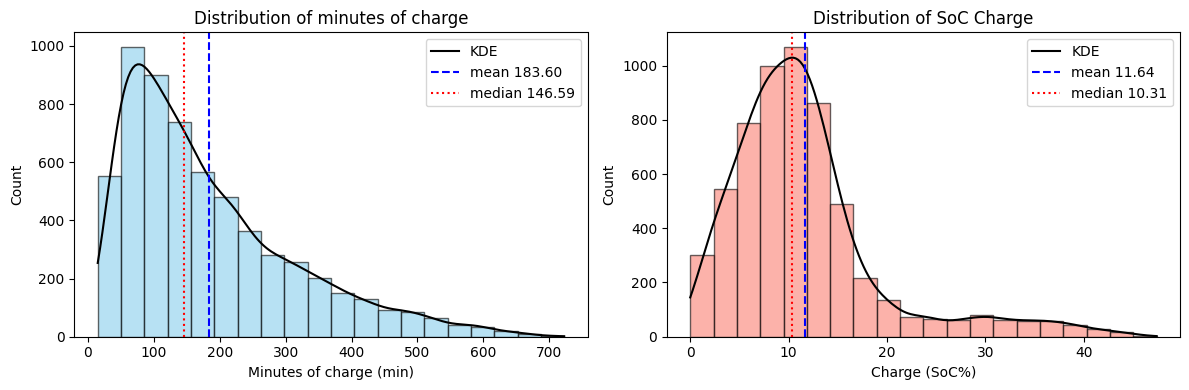

In [21]:
def plot_hist_with_kde(series, ax, color, title, xlabel, bins=20):
    # Ensure numeric and drop NaNs / infs
    y = pd.to_numeric(series, errors='coerce').replace([np.inf, -np.inf], np.nan).dropna().values
    if y.size == 0:
        ax.text(0.5, 0.5, "No data", ha='center', va='center')
        ax.set_title(title)
        return

    # Histogram (counts)
    counts, bin_edges, _ = ax.hist(y, bins=bins, density=False,
                                   alpha=0.6, color=color, edgecolor='black')

    # KDE scaled to match histogram counts
    try:
        from scipy.stats import gaussian_kde
        kde = gaussian_kde(y)
        x_grid = np.linspace(y.min(), y.max(), 200)
        # scale KDE to counts
        kde_vals = kde(x_grid) * len(y) * (bin_edges[1] - bin_edges[0])
        ax.plot(x_grid, kde_vals, color='k', lw=1.5, label='KDE')
    except ImportError:
        pass  # skip KDE if SciPy not available

    # Mean & median vertical lines
    ax.axvline(y.mean(), color='blue', linestyle='--', label=f'mean {y.mean():.2f}')
    ax.axvline(np.median(y), color='red', linestyle=':', label=f'median {np.median(y):.2f}')

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Count')
    ax.legend()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_hist_with_kde(charge_data.get('duration_minutes', pd.Series(dtype=float)), axes[0],
                   color='skyblue', title='Distribution of minutes of charge', xlabel='Minutes of charge (min)')

plot_hist_with_kde(charge_data.get('charge', pd.Series(dtype=float)), axes[1],
                   color='salmon', title='Distribution of SoC Charge', xlabel='Charge (SoC%)')

plt.tight_layout()
plt.show()

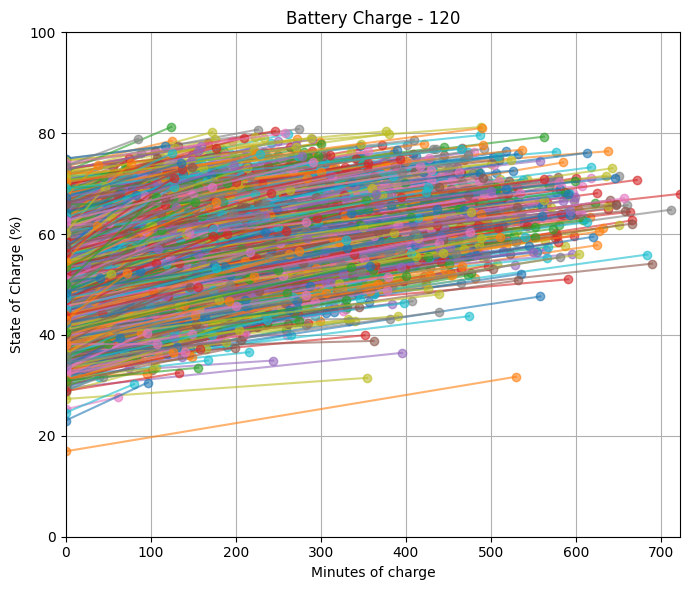

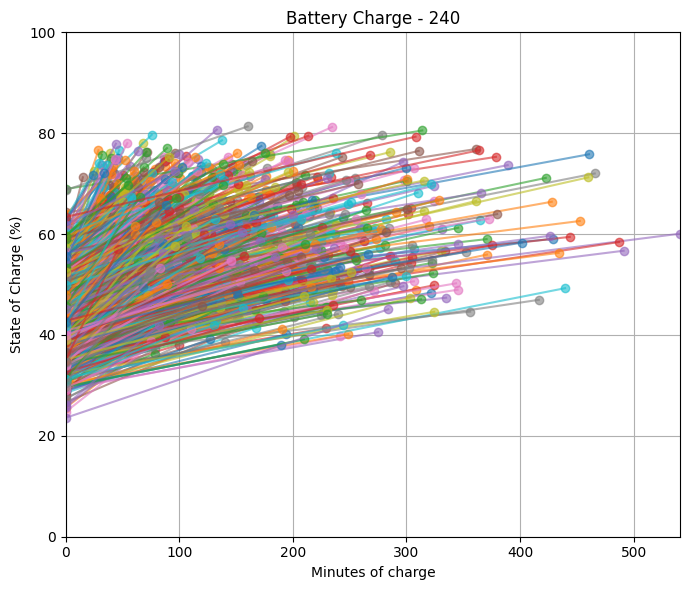

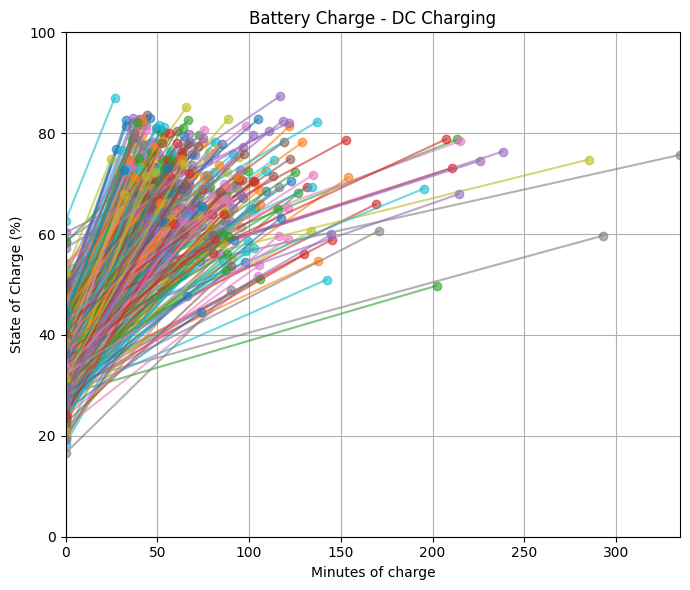

In [23]:
# --- Matplotlib version ---
# Dictionary to map charge_mode to plot title
mode_titles = {
    1: '120',
    2: '240',
    3: 'DC Charging'
}

for mode, title in mode_titles.items():
    # Filter the data for the current charge mode
    filtered_data = charge_data[charge_data['charge_mode'] == mode]

    # Max min for x-axis scaling based on filtered data
    max_minutes = filtered_data['duration_minutes'].max()

    fig, ax = plt.subplots(figsize=(7, 6))

    for _, row in filtered_data.iterrows():
        x_vals = [0, row['duration_minutes']]
        y_vals = [row['soc'], row['end_soc']]
        ax.plot(x_vals, y_vals, marker='o', alpha=0.6)

    ax.set_title(f'Battery Charge - {title}')
    ax.set_xlabel('Minutes of charge')
    ax.set_ylabel('State of Charge (%)')
    ax.set_xlim(0, max_minutes)
    ax.set_ylim(0, 100)
    ax.grid(True)
    plt.tight_layout()
    plt.show()

# --- Plotly version ---

for mode, title in mode_titles.items():
    # Filter the data for the current charge mode
    filtered_data = charge_data[charge_data['charge_mode'] == mode]

    # Reset index to ensure a fresh index for each filtered dataframe
    filtered_data = filtered_data.reset_index(drop=True)

    colors = px.colors.qualitative.Plotly
    fig = go.Figure()

    for color_idx, (_, row) in enumerate(filtered_data.iterrows()):
        fig.add_trace(
            go.Scatter(
                x=[0, row['duration_minutes']],
                y=[row['soc'], row['end_soc']],
                mode='lines+markers',
                opacity=0.5,
                line=dict(color=colors[color_idx % len(colors)], width=2),
                marker=dict(size=6),
                name=f"charge {row.name}",
                hovertemplate=(
                    f"charge index: {row.name}<br>"
                    f"SOC start: {row['soc']}%<br>"
                    f"SOC end: {row['end_soc']}%<br>"
                    f"Min of charge: {row['duration_minutes']} min<br>"
                )
            )
        )

    max_minutes = filtered_data['duration_minutes'].max()
    fig.update_xaxes(title_text='Minutes of charge', range=[0, max_minutes])
    fig.update_yaxes(title_text='State of Charge (%)', range=[0, 100])

    fig.update_layout(
        title=f"Battery Charge - {title}",
        height=500,
        width=700,
        showlegend=False,
        hovermode='closest'
    )
    fig.show()

In [24]:
charge_data['charge_per_min'].describe()

count    5963.000000
mean        0.113936
std         0.168976
min         0.000009
25%         0.034222
50%         0.055563
75%         0.106770
max         1.099215
Name: charge_per_min, dtype: float64

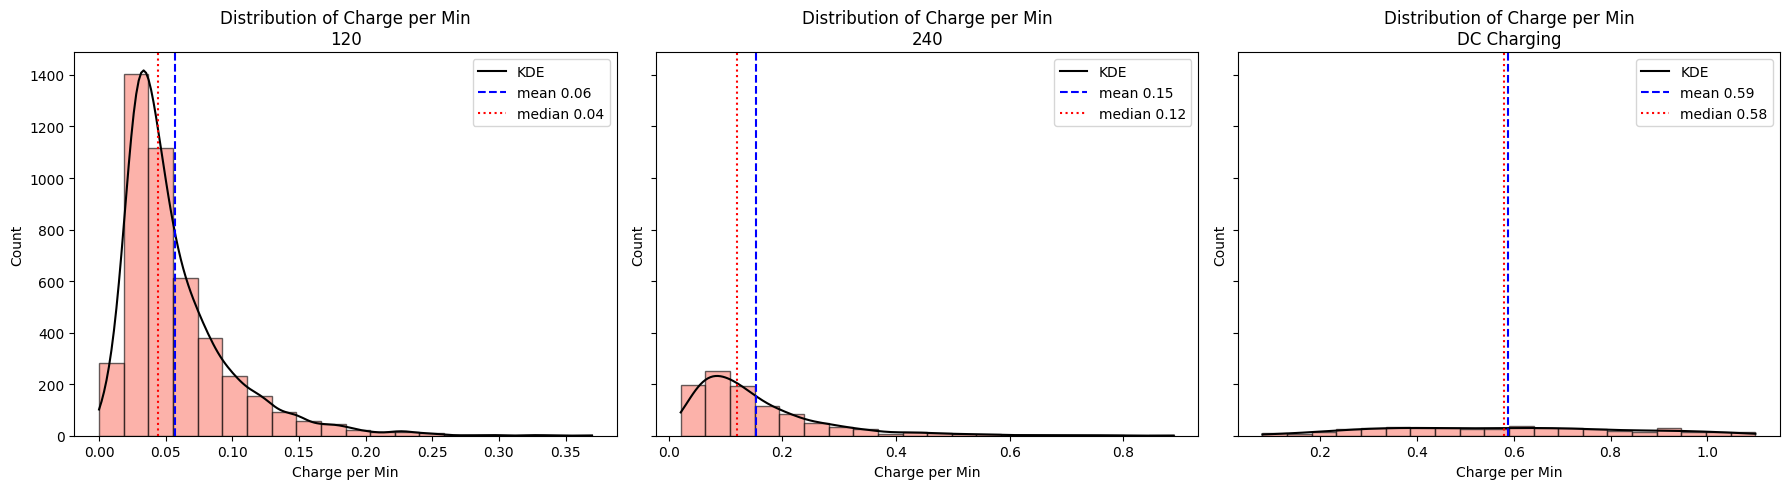

In [25]:
# --- Distribution of Charge per min ---

# Map charge_mode values to labels
charge_labels = {1: "120", 2: "240", 3: "DC Charging"}

# Create a figure with 3 subplots, one for each charge_mode
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, mode in enumerate([1, 2, 3]):
    data_mode = charge_data.loc[charge_data['charge_mode'] == mode, 'charge_per_min']
    ax = axes[i]
    plot_hist_with_kde(data_mode, ax,
                       color='salmon',
                       title=f"Distribution of Charge per Min\n{charge_labels[mode]}",
                       xlabel='Charge per Min')

axes[0].set_ylabel('Count')  # common y-axis label
plt.tight_layout()
plt.show()


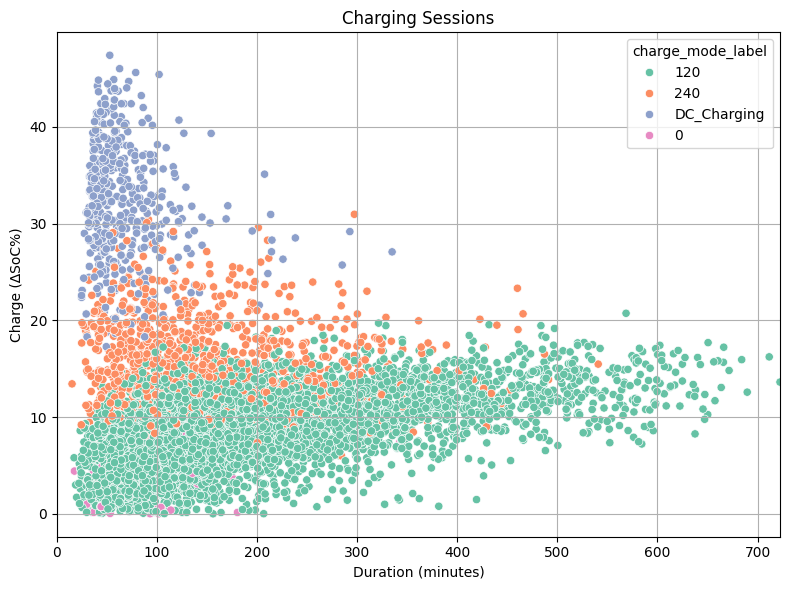

In [26]:
"""
Scatterplot of duration vs. charge,
colored by charge_mode (mapped to labels).
"""
# Mapping of charge_mode
charge_mode_map = {
    0: "0",
    1: "120",
    2: "240",
    3: "DC_Charging"
}
charge_data = charge_data.copy()
charge_data["charge_mode_label"] = charge_data["charge_mode"].map(charge_mode_map)

max_duration = charge_data["duration_minutes"].max()

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=charge_data,
    x="duration_minutes",
    y="charge",
    hue="charge_mode_label",
    palette="Set2",   # use a default color palette
    legend="auto"
)

plt.title("Charging Sessions")
plt.xlim(0, max_duration)
plt.xlabel("Duration (minutes)")
plt.ylabel("Charge (∆SoC%)")
plt.grid(True)
plt.tight_layout()
plt.show()


## Original dataset

In [27]:
charge_data_original = pd.read_csv('./datasets/vehicle_2_47174e+18.csv')
charge_data_original = charge_data_original[charge_data_original['event'] == 'charge'].reset_index(drop=True)
charge_data_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   vin          238 non-null    float64
 1   timestamp    238 non-null    object 
 2   end_time     238 non-null    object 
 3   odo          238 non-null    float64
 4   end_odo      238 non-null    float64
 5   soc          238 non-null    float64
 6   end_soc      238 non-null    float64
 7   event        238 non-null    object 
 8   charge_mode  238 non-null    object 
dtypes: float64(5), object(4)
memory usage: 16.9+ KB


In [28]:
# Remove duplicates
charge_data_original = charge_data_original.drop_duplicates()

# Print how many rows remain
print(f"Number of rows after removing duplicates: {len(charge_data_original)}")

charge_data_original['discharge'] = charge_data_original['soc'] - charge_data_original['end_soc']

# Convert timestamps to datetime
charge_data_original['timestamp'] = pd.to_datetime(charge_data_original['timestamp'], errors='coerce')
charge_data_original['end_time'] = pd.to_datetime(charge_data_original['end_time'], errors='coerce')

# Compute event duration in minutes
charge_data_original['duration_minutes'] = (charge_data_original['end_time'] - charge_data_original['timestamp']).dt.total_seconds() / 60

print("\n🔋 Statistics on Charge:\n", -charge_data_original['discharge'].describe())

Number of rows after removing duplicates: 238

🔋 Statistics on Charge:
 count   -238.000000
mean      16.743697
std      -14.980801
min       52.900000
25%       29.400000
50%       12.600000
75%        2.400000
max        0.300000
Name: discharge, dtype: float64


In [29]:
charge_data_original['min_per_perc_of_battery'] = charge_data_original.apply(
    lambda row: row['duration_minutes'] / -row['discharge'] if row['discharge'] != 0 else 0,
    axis=1
)

charge_data_original['charge_per_min'] = charge_data_original.apply(
    lambda row: -row['discharge'] / row['duration_minutes'] if row['duration_minutes'] != 0 else 0,
    axis=1
)


In [30]:
MAX_CHARGE_PER_MIN = 1.10
##########################################################



anomalous_rows_charge = charge_data_original[(charge_data_original['charge_per_min'] > MAX_CHARGE_PER_MIN)]
print(f"Number of anamalous rows: {anomalous_rows_charge.shape[0]}")

charge_data_original = charge_data_original[~(charge_data_original['charge_per_min'] > MAX_CHARGE_PER_MIN)].reset_index(drop=True)
anomalous_rows_charge.head(len(anomalous_rows_charge ))

Number of anamalous rows: 4


,vin,timestamp,end_time,odo,end_odo,soc,end_soc,event,charge_mode,discharge,duration_minutes,min_per_perc_of_battery,charge_per_min
0,-2.471740e+18,2021-04-29 10:46:00,2021-04-29 11:17:00,2286.71875,2286.734375,24.3,59.2,charge,DCCharging,-34.9,31.0,0.888252,1.125806
112,-2.471740e+18,2021-06-07 22:55:00,2021-06-07 23:26:00,11661.75000,11661.750000,29.8,65.0,charge,DCCharging,-35.2,31.0,0.880682,1.135484
155,-2.471740e+18,2021-06-19 00:21:00,2021-06-19 00:51:00,15289.43750,15289.437500,29.8,64.3,charge,DCCharging,-34.5,30.0,0.869565,1.150000
223,-2.471740e+18,2021-07-15 20:12:00,2021-07-15 20:27:00,22365.68750,22365.687500,28.2,44.7,charge,DCCharging,-16.5,15.0,0.909091,1.100000


In [31]:
charge_data_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234 entries, 0 to 233
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   vin                      234 non-null    float64       
 1   timestamp                234 non-null    datetime64[ns]
 2   end_time                 234 non-null    datetime64[ns]
 3   odo                      234 non-null    float64       
 4   end_odo                  234 non-null    float64       
 5   soc                      234 non-null    float64       
 6   end_soc                  234 non-null    float64       
 7   event                    234 non-null    object        
 8   charge_mode              234 non-null    object        
 9   discharge                234 non-null    float64       
 10  duration_minutes         234 non-null    float64       
 11  min_per_perc_of_battery  234 non-null    float64       
 12  charge_per_min           234 non-nul

In [32]:
charge_data_original['charge_per_min'].describe()

count    234.000000
mean       0.315632
std        0.403376
min        0.006780
25%        0.019405
50%        0.076364
75%        0.816327
max        1.087097
Name: charge_per_min, dtype: float64

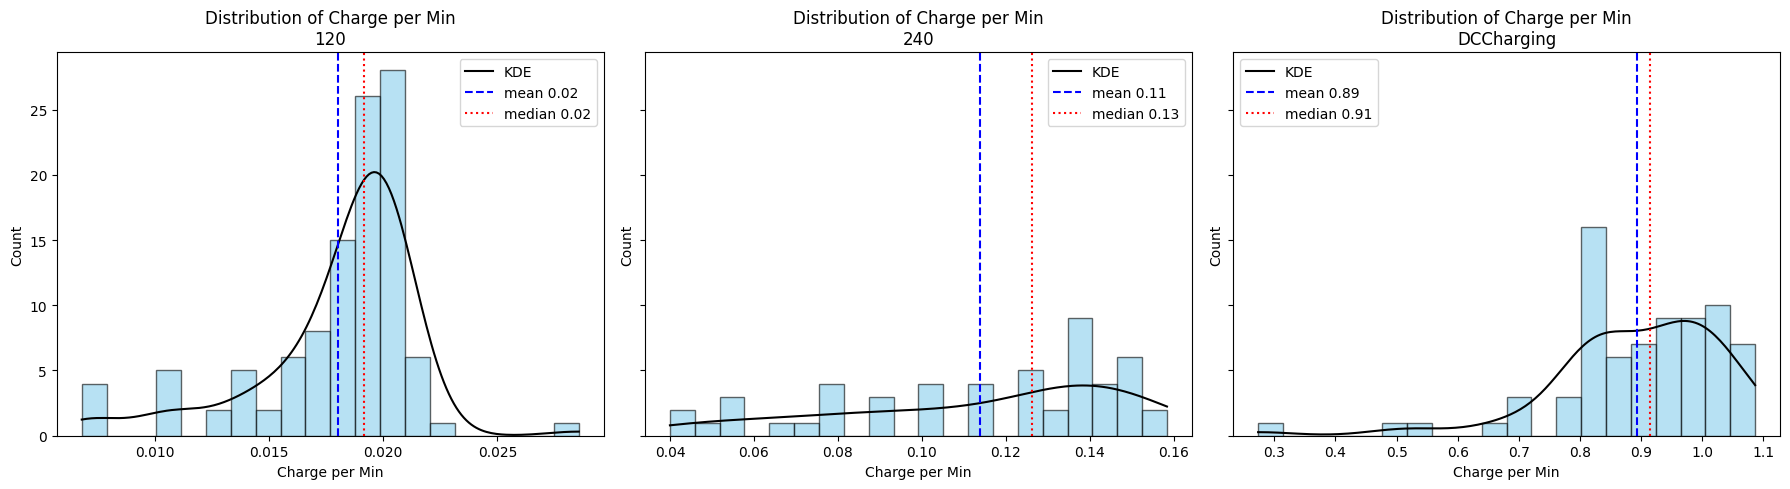

In [33]:
# --- Distribution of Charge per min ---

# Create a figure with 3 subplots, one for each charge_mode
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, mode in enumerate(['120', '240', 'DCCharging']):
    data_mode = charge_data_original.loc[charge_data_original['charge_mode'] == mode, 'charge_per_min']
    ax = axes[i]
    plot_hist_with_kde(data_mode, ax,
                       color='skyblue',
                       title=f"Distribution of Charge per Min\n{mode}",
                       xlabel='Charge per Min')

axes[0].set_ylabel('Count')  # common y-axis label
plt.tight_layout()
plt.show()


## DO NOT CONSIDER FOLLOWING CELL

In [125]:
# TAKE DATA ./Data_saved/Global/Generated_data_vin2_400epochs/kaggle/working/KoVAE/Generated_data/EV_generated_data.csv
data = pd.read_csv('./Data_saved/Global/Generated_data_vin2_400epochs/kaggle/working/KoVAE/Generated_data/EV_generated_data.csv')
# print columns
print(data.columns)

# load also trip_Data and charge_data and then filter data, keeping only rows present in trip_data and charge_data
trip_data = pd.read_csv('./Data_saved/Global/Generated_data_vin2_400epochs/kaggle/working/KoVAE/Generated_data/trips_EV_generated_data.csv')

#take only 'odo', 'end_odo', 'soc', 'end_soc', 'event', 'charge_mode','duration_minutes'
trip_data = trip_data[['id']]
charge_data_1 = pd.read_csv('./Data_saved/Global/Generated_data_vin2_400epochs/kaggle/working/KoVAE/Generated_data/charges_EV_generated.csv')

# take only 'odo', 'end_odo', 'soc', 'end_soc', 'event', 'charge_mode','duration_minutes'
charge_data_1 = charge_data_1[[ 'id']]


# keep rows that are present in ids of trip_data and charge_data
data['id'] = data.index

data = data[data['id'].isin(trip_data['id']) | data['id'].isin(charge_data_1['id'])]

#drop columns 'id'
data = data.drop(columns=['id'])

#when event = 1 --> set end_odo = odo 
data.loc[data['event'] == 1, 'end_odo'] = data['odo']

# add in first position column 'vin', all rows with value -2.47174E+18
data.insert(0, 'vin', -2.47174E+18)


# map event 0 -> trip, 1 -> charge
data['event'] = data['event'].map({0: 'trip', 1: 'charge'})
# map charge_mode 1 -> 120, 2 -> 240, 3 -> DC Charging
data['charge_mode'] = data['charge_mode'].map({0: 0, 1: 120, 2: 240, 3: 'DC Charging'})
data.to_csv('./Data_saved/Global/Generated_data_vin2_400epochs/kaggle/working/KoVAE/Generated_data/EV_generated_data_final.csv', index=False)

Index(['odo', 'end_odo', 'soc', 'end_soc', 'event', 'charge_mode',
       'duration_minutes'],
      dtype='object')
